# Fitting Rubin DP1 light curves with LSDB

This notebook demonstrates how to load DP1 data using LSDB and run EzTaoX fitting on DP1 light curves. 

### Set up a virtual environment

To run this notebook on the RSP please create a virtual environment with conda as follows:

```bash
conda create -n eztaox python=3.12
conda activate eztaox
pip install eztaox lsdb jupyter arviz netCDF4 matplotlib
python -m ipykernel install --user --name eztaox --display-name "EzTaoX (Python 3.12)"
```

You should now be able to select the EzTaoX kernel from your Jupyter notebook.

In [1]:
from upath import UPath

import numpy as np
import matplotlib.pyplot as plt
import arviz as az

import os
import lsdb
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax
import pyarrow as pa

from dask.distributed import Client
from eztaox.kernels.quasisep import Exp
from eztaox.models import MultiVarModel
from eztaox.fitter import random_search
from nested_pandas import NestedDtype
from numpyro.infer import MCMC, NUTS, init_to_median
from numpyro.diagnostics import summary

### 1. Load DP1 light curves

First, let’s load the DP1 light curves with LSDB. For this notebook, we will only load long light curves with `nDiaSources` > 500 and the necessary `diaObjectForcedSource` columns.

In [2]:
dia_object_cat = lsdb.open_catalog(
    "/rubin/lsdb_data/dia_object_collection",
    columns=["ra", "dec", "diaObjectId", "nDiaSources", "diaObjectForcedSource"],
    filters=[["nDiaSources", ">", 500]],
)
print(f"Number of DIA objects in DP1: {len(dia_object_cat):,}")

Number of DIA objects in DP1: 1,089,818


In [3]:
dia_object_cat.head()

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
2528665081895373202  53.122135 -28.344551  609788873886662663          512   
2528689212471481767  53.041797 -28.283192  609789629800906756          581   
2528689652733440700  53.033514 -28.243268  611253766972244112          567   
2528691786073128755  52.898762 -28.193302  611253766972243969          548   
2528711291375799141  53.321787 -28.312488  609789492361953287          513   

                                                 diaObjectForcedSource  
_healpix_29                                                             
2528665081895373202  [{parentObjectId: 0, coord_ra: 53.122135, coor...  
2528689212471481767  [{parentObjectId: 0, coord_ra: 53.041797, coor...  
2528689652733440700  [{parentObjectId: 0, coord_ra: 53.033514, coor...  
2528691786073128755  [{parentObjectId: 0, coord_ra: 52.898762, coor...  
2528711291375799141  [{parentObjectId: 0, coord_ra: 53.321787, coor...

### 1.1 Clean light curves

We will remove all observations with a flag, and keep only objects with detections in both the r and i bands. 

#### Remove objects with flags

In [4]:
flag_subcols = [
    c for c in dia_object_cat["diaObjectForcedSource"].columns if "flag" in c.lower()
]
dia_object_cat = dia_object_cat.query(
    " and ".join([f"diaObjectForcedSource.{c} != 1" for c in flag_subcols])
)

#### Select two bands, r and i

In [5]:
dia_object_cat = dia_object_cat.query("diaObjectForcedSource.band in ['r','i']")

#### Remove NA values

- Remove all forced sources with NA mjds/mags.
- Remove all objects that after filtering have no forced sources.

In [6]:
def remove_na_sources(df):
    subcols = [
        f"diaObjectForcedSource.{subcol}"
        for subcol in ["midpointMjdTai", "psfMag", "psfMagErr"]
    ]
    return df.dropna(subset=subcols).dropna(subset="diaObjectForcedSource")


dia_object_cat = dia_object_cat.map_partitions(remove_na_sources)
dia_object_cat

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource
npartitions=208,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 6, Pixel: 136",...,...,...,...,...
...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...


We will also clean the light curves by:
- removing 10-sigma outliers within each night
- binning the data into nightly epochs by taking the mean magnitude for each night 
- updating the magnitude uncertainties by adding, in quadrature, the mean magnitude error and the within-night standard deviation of the magnitudes

In [7]:
def prepare_lightcurves(
    time: np.ndarray,
    band: np.ndarray,
    mag: np.ndarray,
    magerr: np.ndarray,
    outlier_snr: float = 10.0,
    binning: bool = True,
) -> dict[str, np.ndarray]:
    """
    Clean light curves by removing outliers and optionally binning by epoch.

    Args:
        time:        Timestamps (MJD).
        band:        Band labels.
        mag:         Magnitudes.
        magerr:      Magnitude errors.
        outlier_snr: Sigma threshold for outlier rejection.
        binning:     If True, combine observations within the same epoch.
    """
    times, mags, magerrs = {}, {}, {}

    for b in np.unique(band):
        band_mask = band == b
        time_band, mag_band, magerr_band = (
            time[band_mask],
            mag[band_mask],
            magerr[band_mask],
        )

        time_band, mag_band, magerr_band = remove_outliers(
            time_band, mag_band, magerr_band, outlier_snr
        )

        if binning:
            t, _, m, me = bin_band(time_band, mag_band, magerr_band, b)
        else:
            t, _, m, me = time_band, np.full(len(time_band), b), mag_band, magerr_band

        times[b] = t
        mags[b] = m
        magerrs[b] = me

    return format_lightcurves(times, mags, magerrs)


def remove_outliers(
    time_band: np.ndarray,
    mag_band: np.ndarray,
    magerr_band: np.ndarray,
    outlier_snr: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Remove data points beyond outlier_snr standard deviations from the mean."""
    if len(time_band) <= 1 or np.nanstd(mag_band) == 0:
        return time_band, mag_band, magerr_band

    sigma = np.abs(mag_band - np.nanmean(mag_band)) / np.nanstd(mag_band)
    mask = sigma < outlier_snr
    return time_band[mask], mag_band[mask], magerr_band[mask]


def bin_band(
    time_band: np.ndarray,
    mag_band: np.ndarray,
    magerr_band: np.ndarray,
    band_label: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Bin observations by epoch (rounded to nearest day) and combine magnitudes."""
    rounded_times = np.round(time_band)
    unique_epochs = np.unique(rounded_times)

    binned_times, binned_mags, binned_magerrs = [], [], []
    for epoch in unique_epochs:
        epoch_mask = rounded_times == epoch
        tmp_mag, tmp_err = combine_mag(mag_band[epoch_mask], magerr_band[epoch_mask])
        binned_times.append(epoch)
        binned_mags.append(tmp_mag)
        binned_magerrs.append(tmp_err)

    binned_bands = np.full(len(unique_epochs), band_label)
    return (
        np.array(binned_times),
        binned_bands,
        np.array(binned_mags),
        np.array(binned_magerrs),
    )


def combine_mag(mag, mag_err):
    """Add in quaduature mean(magerr) and std(mag) in each epoch
    ## e.g., https://arxiv.org/abs/2411.06617"""
    mag = np.asarray(mag)
    mag_err = np.asarray(mag_err)
    mag_w = np.nanmean(mag)
    mag_w_err = np.sqrt(np.nanmean(mag_err) ** 2 + np.nanstd(mag) ** 2)
    return mag_w, mag_w_err


def format_lightcurves(times, mags, magerrs):
    """Prepare light curves for fitting"""
    bands = times.keys()
    inds = jnp.argsort(jnp.concatenate([times[b] for b in bands]))
    X = (
        jnp.concatenate([times[b] for b in bands])[inds],
        jnp.concatenate(
            [i * jnp.ones_like(times[b], dtype=int) for i, b in enumerate(bands)]
        )[inds],
    )
    for b in bands:
        mags[b] = jnp.array(mags[b])
        mags[b] -= jnp.median(mags[b])
    y = jnp.concatenate([jnp.array(mags[b]) for b in bands])[inds]
    yerr = jnp.concatenate([jnp.array(magerrs[b]) for b in bands])[inds]
    return X, y, yerr

### 2. EzTaoX fitting

First, we need to define a init sampler:

In [8]:
def init_sampler(fixed_params=None):
    if fixed_params is None:
        fixed_params = {}

    if "log_drw_scale" in fixed_params:
        log_drw_scale = fixed_params["log_drw_scale"]
    else:
        log_drw_scale = numpyro.sample(
            "log_drw_scale", dist.Uniform(jnp.log(10), jnp.log(100))
        )
    if "log_drw_sigma" in fixed_params:
        log_drw_sigma = fixed_params["log_drw_sigma"]
    else:
        log_drw_sigma = numpyro.sample(
            "log_drw_sigma", dist.Uniform(jnp.log(1e-2), jnp.log(10))
        )
    log_kernel_param = jnp.stack([log_drw_scale, log_drw_sigma])
    numpyro.deterministic("log_kernel_param", log_kernel_param)

    # parameters to relate the amplitudes in each band
    log_amp_scale = numpyro.sample("log_amp_scale", dist.Uniform(-2, 2))

    mean = numpyro.sample(
        "mean",
        dist.Uniform(low=jnp.asarray([-0.1, -0.1]), high=jnp.asarray([0.1, 0.1])),
    )

    # interband lags
    lag = numpyro.sample("lag", dist.Uniform(-10, 10))

    sample_params = {
        "log_kernel_param": log_kernel_param,
        "log_amp_scale": log_amp_scale,
        "mean": mean,
        "lag": lag,
    }
    return sample_params


def numpyro_model(m, fixed_params=None):
    sample_params = init_sampler(fixed_params)
    m.sample(sample_params)

And instantiate a multivariate model to use for fitting:

In [9]:
def run_MCMC(
    objid,
    X,
    y,
    yerr,
    numpyro_model,
    has_lag=True,
    zero_mean=True,
    fixed_params=None,
    save_chains=False,
):
    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)

    nuts_kernel = NUTS(
        numpyro_model,
        dense_mass=True,
        target_accept_prob=0.9,
        init_strategy=init_to_median,
    )
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=500,
        num_samples=1000,
        num_chains=1,
        # progress_bar=False,
    )
    mcmc_seed = jax.random.PRNGKey(0)
    mcmc.run(mcmc_seed, m, fixed_params)

    if save_chains:
        idata = az.from_numpyro(mcmc)
        output_path = UPath(f"mcmc_chains/{objid}.nc")
        output_path.parent.mkdir(parents=True, exist_ok=True)
        idata.to_netcdf(str(output_path))

    return summary(mcmc.get_samples(group_by_chain=True))

Let's finally put these steps all together:

In [10]:
def run_eztaox(objid, times, band, mag, magerr):
    X, y, yerr = prepare_lightcurves(times, band, mag, magerr)
    mcmc_summary = run_MCMC(
        objid,
        X,
        y,
        yerr,
        numpyro_model,
        has_lag=True,
        zero_mean=True,
        fixed_params={"log_drw_scale": jnp.log(100.0)},
        save_chains=True,
    )
    return make_nested(mcmc_summary)


def make_nested(summary):
    nested_dict = {}
    for key in summary:
        for key2 in summary[key]:
            nested_dict[f"{key}.{key2}"] = [summary[key][key2]]
    return nested_dict

Plan the computation and run it in parallel with LSDB:

In [11]:
# Stats returned by the mcmc summary
nested_subcols = ["mean", "std", "median", "5.0%", "95.0%", "n_eff", "r_hat"]

# Params returned by the mcmc summary
nested_cols = ["lag", "log_amp_scale", "log_drw_sigma", "log_kernel_param", "mean"]

# Metadata for the catalog operation
meta = {
    col: NestedDtype({sc: pa.float64() for sc in nested_subcols}) for col in nested_cols
}

In [12]:
result = dia_object_cat.map_rows(
    run_eztaox,
    # We only need the forced sources time band and mag info
    columns=["diaObjectId"]
    + [
        f"diaObjectForcedSource.{col}"
        for col in ["midpointMjdTai", "band", "psfMag", "psfMagErr"]
    ],
    row_container="args",
    append_columns=True,
    meta=meta,
)
result

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource,lag,log_amp_scale,log_drw_sigma,log_kernel_param,mean
npartitions=208,,,,,,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ..."
"Order: 6, Pixel: 136",...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...,...,...,...,...,...


In [13]:
with Client(n_workers=4):
    fitting_df = result.compute()
fitting_df

sample: 100%|██████████| 1500/1500 [00:05<00:00, 289.89it/s, 15 steps of size 3.34e-01. acc. prob=0.95]


ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
2528665081895373202  53.122135 -28.344551  609788873886662663          512   
2528689212471481767  53.041797 -28.283192  609789629800906756          581   
...                        ...        ...                 ...          ...   
2528746659668617474   52.95461 -27.948373  611255141361778689          552   
2528749594173367688  53.137026 -27.863437  611255072642301964          559   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
2528665081895373202  [{parentObjectId: 0, coord_ra: 53.122135, coor...   
2528689212471481767  [{parentObjectId: 0, coord_ra: 53.041797, coor...   
...                                                                ...   
2528746659668617474  [{parentObjectId: 0, coord_ra: 52.95461, coord...   
2528749594173367688  [{parentObjectId: 0, coord_ra: 53.137026, coor...   

                                                                   lag  \
_healpix_29                                                              
2528665081895373202  [{mean: 0.114068, std: 5.737555, median: 0.475...   
2528689212471481767  [{mean: 0.578621, std: 5.238823, median: 0.881...   
...                                                                ...   
2528746659668617474  [{mean: 0.436035, std: 5.167102, median: 0.478...   
2528749594173367688  [{mean: 0.440975, std: 5.791534, median: 0.707...   

                                                         log_amp_scale  \
_healpix_29                                                              
2528665081895373202  [{mean: -1.209215, std: 0.57737, median: -1.30...   
2528689212471481767  [{mean: -0.832439, std: 0.667594, median: -0.8...   
...                                                                ...   
2528746659668617474  [{mean: -0.565345, std: 0.429817, median: -0.5...   
2528749594173367688  [{mean: -0.993726, std: 0.657626, median: -1.0...   

                                                         log_drw_sigma  \
_healpix_29                                                              
2528665081895373202  [{mean: -4.3326, std: 0.231873, median: -4.389...   
2528689212471481767  [{mean: -4.278913, std: 0.273341, median: -4.3...   
...                                                                ...   
2528746659668617474  [{mean: -4.211317, std: 0.312954, median: -4.2...   
2528749594173367688  [{mean: -4.320783, std: 0.250786, median: -4.3...   

                                                      log_kernel_param  \
_healpix_29                                                              
2528665081895373202  [{mean: array([ 4.60517019, -4.33259951]), std...   
2528689212471481767  [{mean: array([ 4.60517019, -4.27891286]), std...   
...                                                                ...   
2528746659668617474  [{mean: array([ 4.60517019, -4.21131692]), std...   
2528749594173367688  [{mean: array([ 4.60517019, -4.32078254]), std...   

                                                                  mean  
_healpix_29                                                             
2528665081895373202  [{mean: array([ 0.00120897, -0.00309126]), std...  
2528689212471481767  [{mean: array([-0.00384085, -0.00218477]), std...  
...                                                                ...  
2528746659668617474  [{mean: array([ 0.00482644, -0.00460981]), std...  
2528749594173367688  [{mean: array([-0.00032083, -0.00145916]), std...  

[53 rows x 10 columns]

We can load one of the chains as follows:

In [14]:
az.from_netcdf("mcmc_chains/611254385447534607.nc")

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                 (chain: 1, draw: 1000, log_kernel_param_dim_0: 2,
│                                    mean_dim_0: 2)
│       Coordinates:
│         * chain                   (chain) int64 8B 0
│         * draw                    (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * log_kernel_param_dim_0  (log_kernel_param_dim_0) int64 16B 0 1
│         * mean_dim_0              (mean_dim_0) int64 16B 0 1
│       Data variables:
│           lag                     (chain, draw) float64 8kB ...
│           log_amp_scale           (chain, draw) float64 8kB ...
│           log_drw_sigma           (chain, draw) float64 8kB ...
│           log_kernel_param        (chain, draw, log_kernel_param_dim_0) float64 16kB ...
│           mean                    (chain, draw, mean_dim_0) float64 16kB ...
│       Attributes:
│           created_at:                 2026-04-15T14:41:07.195973+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.19.0
├── Group: /sample_stats
│       Dimensions:    (chain: 1, draw: 1000)
│       Coordinates:
│         * chain      (chain) int64 8B 0
│         * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           diverging  (chain, draw) bool 1kB ...
│       Attributes:
│           created_at:                 2026-04-15T14:41:07.203114+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.19.0
└── Group: /observed_data
        Dimensions:   (gp_dim_0: 29)
        Coordinates:
          * gp_dim_0  (gp_dim_0) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
        Data variables:
            gp        (gp_dim_0) float32 116B ...
        Attributes:
            created_at:                 2026-04-15T14:41:07.206919+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.19.0

### 3. Plot some results

In [15]:
def plot_MCMC(
    X, y, yerr, mcmc, outfile=None, trace_vars=None, has_lag=True, zero_mean=True
):
    # Draw one sample from MCMC and extract parameters
    mcmc_samples = {
        k: v.stack(sample=("chain", "draw")).transpose("sample", ...).values
        for k, v in mcmc.posterior.data_vars.items()
    }
    sample_idx = 100  # Use first sample
    params_sample = {k: v[sample_idx] for k, v in mcmc_samples.items()}

    band_colors = {
        "u": "blue",
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
        "y": "brown",
    }

    # Create prediction grid (finer time resolution for smooth curves)
    pred_times = jnp.linspace(X[0].min(), X[0].max(), 200)
    pred_X = (pred_times, jnp.zeros_like(pred_times, dtype=int))  # Band 0

    # Make prediction for each band
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.75, 1], wspace=0.15)

    ax0 = fig.add_subplot(ax[0, 0])
    n_vars = len(trace_vars)
    ax_r = ax[0, 1].subgridspec(nrows=n_vars, ncols=2, hspace=0.4, wspace=0.4)
    ax1 = np.asarray(
        [[fig.add_subplot(ax_r[r, c]) for c in range(2)] for r in range(n_vars)],
        dtype=object,
    )

    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)  # init params for k are not used
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)
    m.sample(params_sample)
    model = m

    for i, b in enumerate("ri"):
        # Create prediction for this band
        pred_X_band = (pred_times, jnp.full_like(pred_times, i, dtype=int))
        mu, std = model.pred(params_sample, pred_X_band)

        # Plot observed data
        mask = X[1] == i

        # Plot prediction
        ax0.plot(pred_times, mu, "-", linewidth=1, alpha=0.5, color=band_colors[b])
        ax0.fill_between(
            pred_times, mu - std, mu + std, alpha=0.2, color=band_colors[b]
        )
        ax0.errorbar(
            X[0][mask],
            y[mask],
            yerr=yerr[mask],
            fmt=".",
            label=b,
            zorder=-100,
            color=band_colors[b],
        )

        ax0.set_xlabel("Time (days)", fontsize=12)
        ax0.set_ylabel("Scaled Magnitude", fontsize=12)
        ax0.tick_params(direction="in")
        ax0.invert_yaxis()
        ax0.legend(loc="upper left")

    for iv, var in enumerate(trace_vars):
        ax1[iv, 0].plot(np.array(mcmc.posterior[var]).flatten())
        ax1[iv, 1].hist(np.array(mcmc.posterior[var]).flatten())
        ax1[iv, 1].set_ylabel(var)
        ax1[iv, 1].yaxis.set_label_position("right")
        ax1[iv, 0].tick_params(direction="in")
        ax1[iv, 1].tick_params(direction="in")

    ax1[0, 0].set_title("Trace")
    ax1[0, 1].set_title("Posterior")

    if outfile != None:
        plt.savefig(outfile, bbox_inches="tight")
    else:
        plt.show()

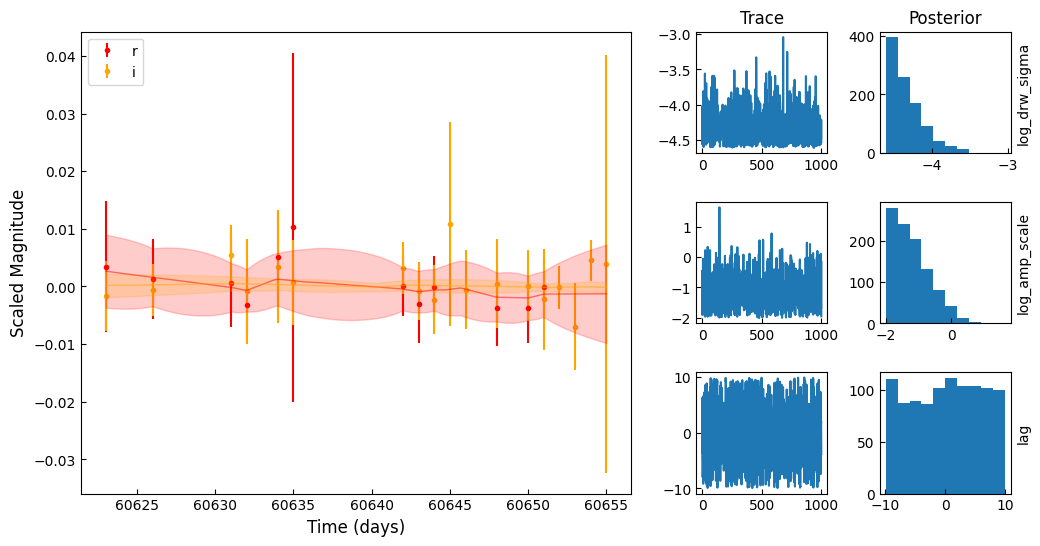

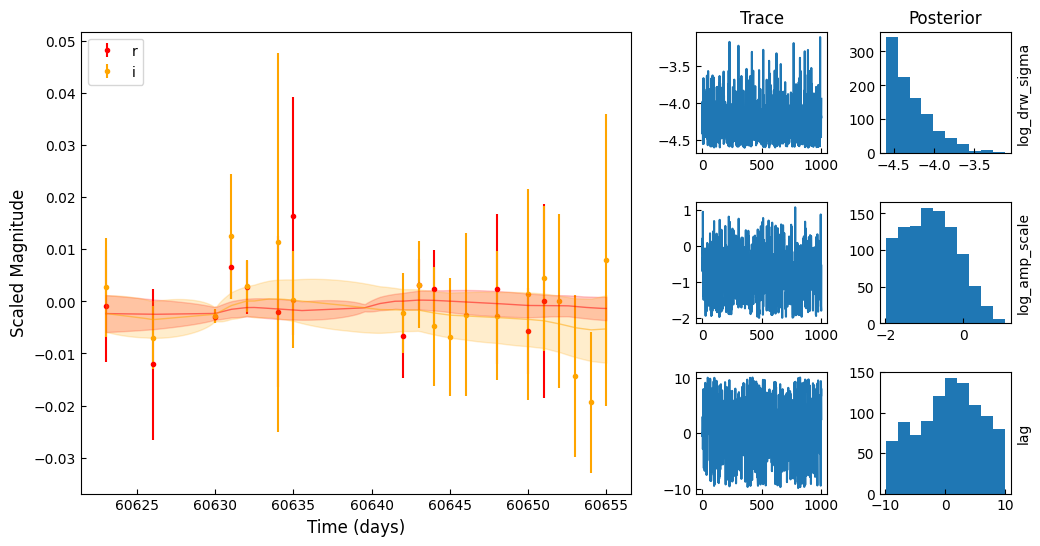

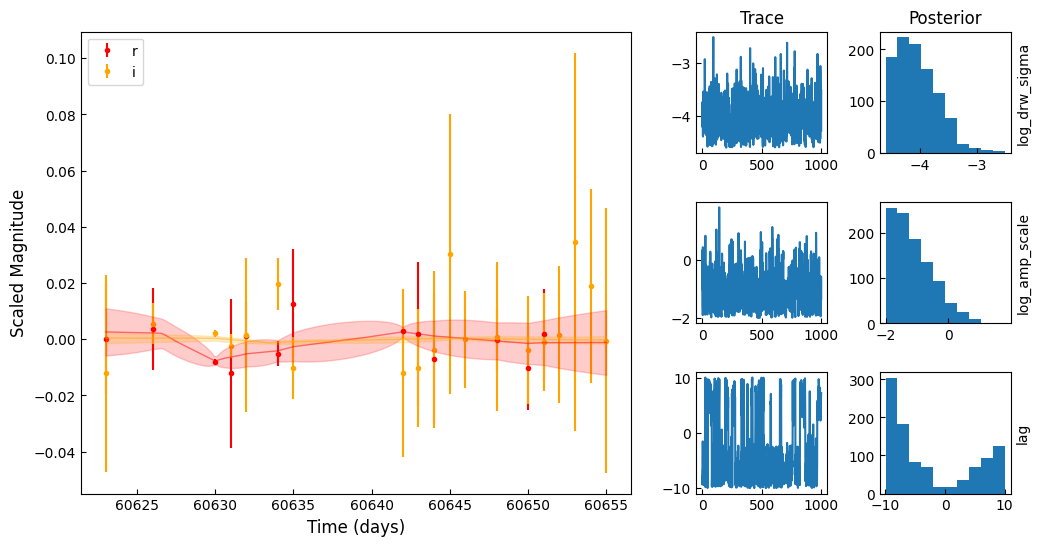

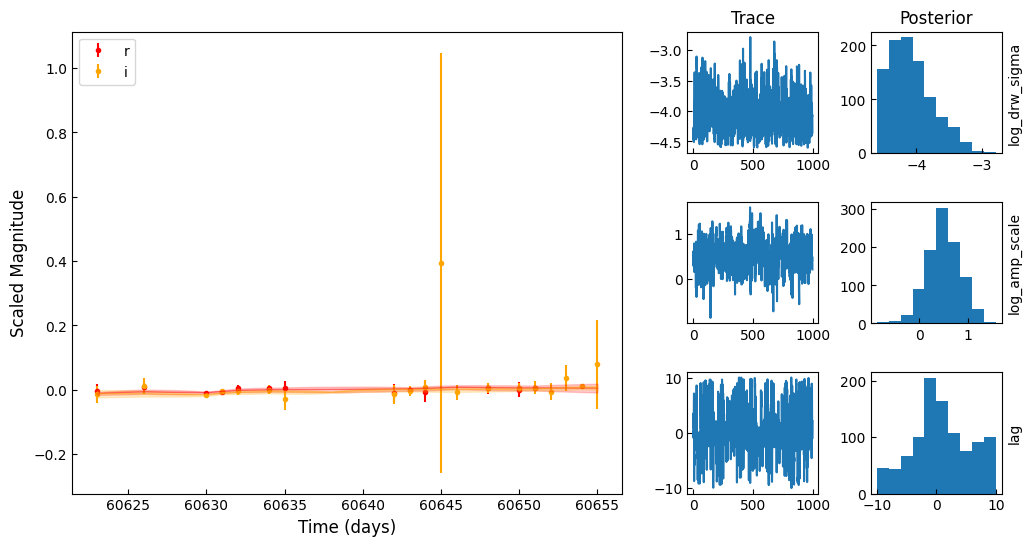

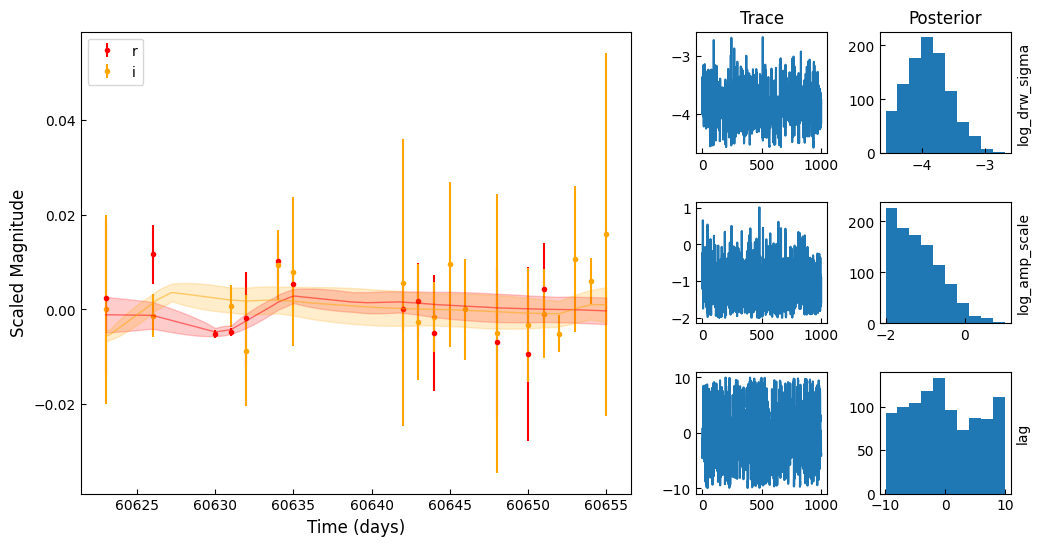

In [16]:
for i in range(5):
    obj = fitting_df.iloc[i]
    X, y, yerr = prepare_lightcurves(
        obj.diaObjectForcedSource["midpointMjdTai"],
        obj.diaObjectForcedSource["band"],
        obj.diaObjectForcedSource["psfMag"],
        obj.diaObjectForcedSource["psfMagErr"],
    )
    plot_MCMC(
        X,
        y,
        yerr,
        az.from_netcdf(f"mcmc_chains/{str(obj.diaObjectId)}.nc"),
        trace_vars=["log_drw_sigma", "log_amp_scale", "lag"],
    )